# Generating simulation datasets\n
This example generates five independent Q2237+0305 image-B realizations with the validated dynamic IPM preset. It uses $N=10^7$, $k=2$, $r=2$, $v=4$, the Taylor far-field approximation, frame-zero $k=1\rightarrow2$ scout normalization, temporal batch 40, and ten-frame endpoint-union scout refreshes. Each realization changes the stellar field and intrinsic broken-PSD driver while retaining the same macroimage and disk parameters.

Fluxes are physical Jy from the disk model and are plotted as AB magnitudes, $m_{\rm AB}=-2.5\log_{10}(f_\nu/3631\,\mathrm{Jy})$. Each row shows both the microlensing-only light curve and the same realization with intrinsic variability. The intrinsic source is evaluated daily while the expensive dynamic maps and source-center labels are evaluated every 25 days. Daily flux uses the two bracketing map--source contractions, so daily maps are never materialized. The three diagnostics reproduce the source-center quantities used in the paper. They are $\log_{10}\mu$, the crossing indicator, and distance to the nearest caustic. Only the center and anchor/gauge queries are evaluated. No full label map is materialized.

The first example includes any missing kernel compilation. Later examples in the same persistent GPU worker reuse those kernels. Each realization changes its star positions, stellar velocities, intrinsic driver, and random seeds without changing the source resolution, band count, temporal batch, dtype, backend, or IPM/far-field shapes. Those physical changes therefore do not require compilation per light curve. Changing a numerical shape can create one new cached specialization.

In [1]:
from pathlib import Path
import json, os, subprocess, sys
import matplotlib.pyplot as plt
import numpy as np
import torch
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
NOTEBOOK_DIR = Path.cwd()
repository_examples = Path(mcp.__file__).resolve().parents[3] / 'examples'
local_examples = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR / 'examples'
EXAMPLES = next(path for path in (local_examples, repository_examples) if (path / 'generate_q2237_training_set.py').is_file())
OUTPUT = NOTEBOOK_DIR / 'generated' / 'q2237_b_training_set'
OUTPUT.mkdir(parents=True, exist_ok=True)
TRITON_CACHE = OUTPUT / 'triton_cache' / 'notebook'
TRITON_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('TRITON_CACHE_DIR', str(TRITON_CACHE.resolve()))
print('CUDA:', torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'portable CPU smoke mode')

CUDA: True NVIDIA GeForce RTX 5070 Ti


In [2]:
command = [sys.executable, str(EXAMPLES / 'generate_q2237_training_set.py'), '--count', '5', '--seed', '17000', '--output-dir', str(OUTPUT), '--overwrite']
if torch.cuda.is_available():
    command += ['--gpus', '0']
else:
    command += ['--device', 'cpu', '--rays', '262144', '--source-resolution', '128', '--label-resolution', '512', '--epochs', '13']
subprocess.run(command, check=True)

CompletedProcess(args=['c:\\Users\\fagin\\miniforge3\\envs\\torch\\python.exe', 'C:\\Users\\fagin\\Desktop\\microlensing\\microcaustics_package\\examples\\generate_q2237_training_set.py', '--count', '5', '--seed', '17000', '--output-dir', 'C:\\Users\\fagin\\Desktop\\microlensing\\microcaustics_package\\build\\notebook_execution\\04_simulation_datasets_jvpwk_6c\\generated\\q2237_b_training_set', '--overwrite', '--gpus', '0'], returncode=0)

first call (compile + execute)=7.618 s
warmed end-to-end LC + center labels median=4.369 s
warmed dynamic maps + center labels median=nan s
warmed map--source contractions median=nan s
warmed physical-source brightness median=nan s
Each row uses 147 dynamic maps/label epochs and 3,651 daily source samples.


C:\Users\fagin\AppData\Local\Temp\ipykernel_524\3660851341.py:10: RuntimeWarning: All-NaN slice encountered
  print(f"warmed dynamic maps + center labels median={np.nanmedian(dynamic_time[1:]):.3f} s")
C:\Users\fagin\AppData\Local\Temp\ipykernel_524\3660851341.py:11: RuntimeWarning: All-NaN slice encountered
  print(f"warmed map--source contractions median={np.nanmedian(contraction_time[1:]):.3f} s")
C:\Users\fagin\AppData\Local\Temp\ipykernel_524\3660851341.py:12: RuntimeWarning: All-NaN slice encountered
  print(f"warmed physical-source brightness median={np.nanmedian(source_time[1:]):.3f} s")


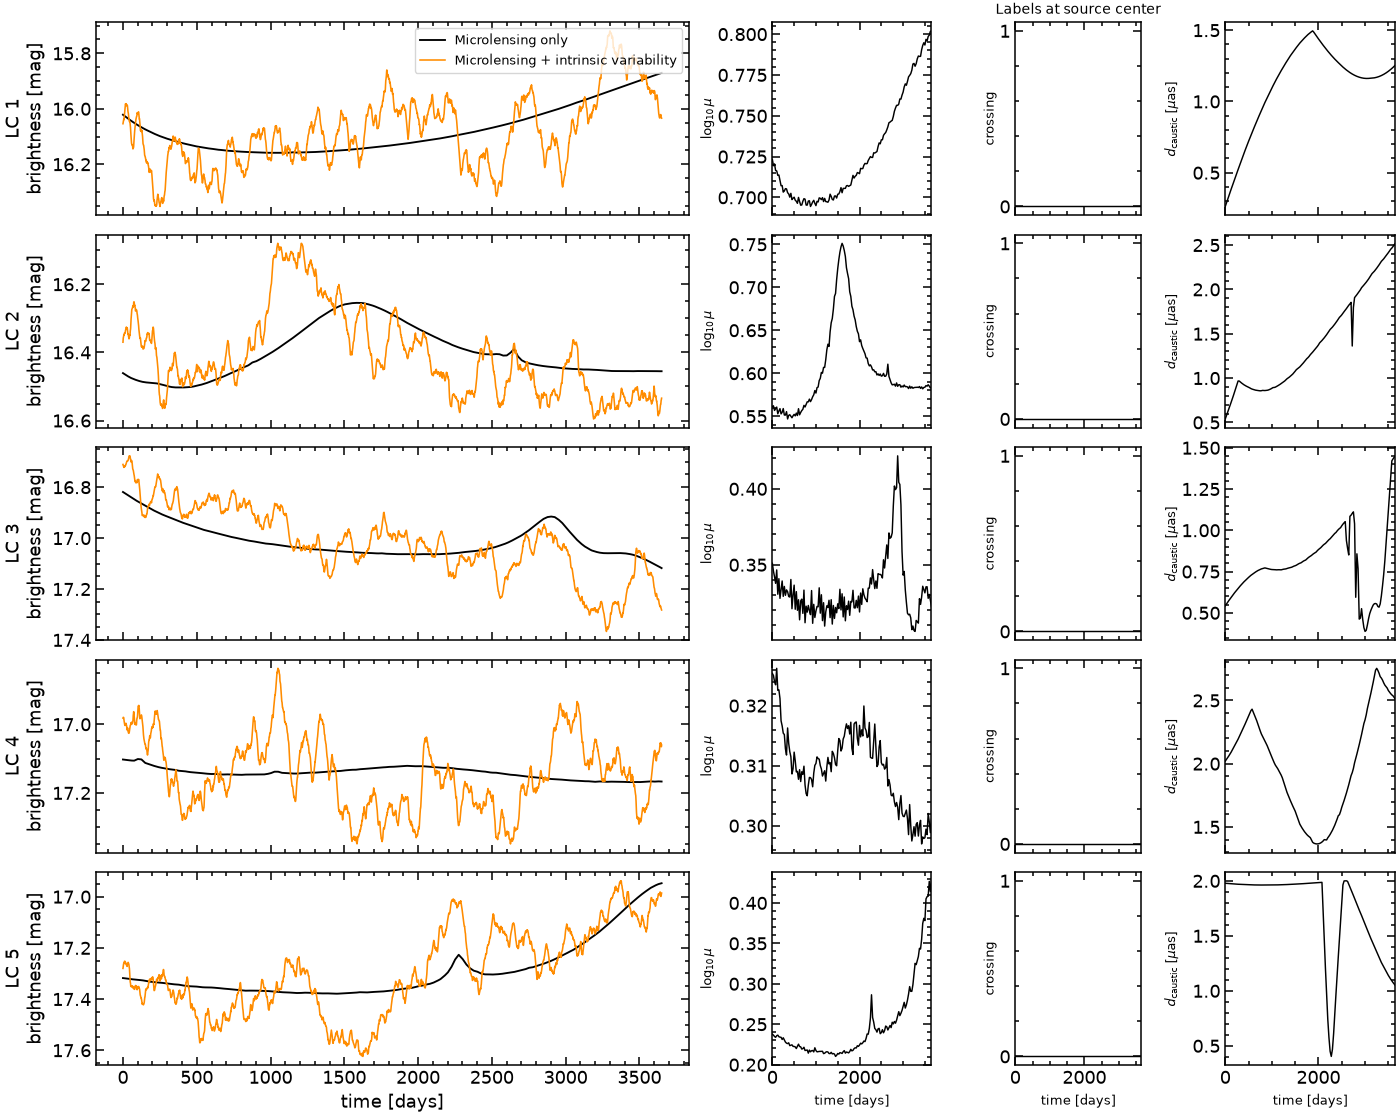

In [3]:
paths = sorted(OUTPUT.glob("light_curve_*.npz"))[:5]
metadata_rows = [json.loads(path.with_suffix(".json").read_text()) for path in paths]
runtimes = np.asarray([row["runtime_seconds"] for row in metadata_rows], dtype=float)
components = [row.get("timing_components_seconds", {}) for row in metadata_rows]
dynamic_time = np.asarray([float(item.get("dynamic_maps", np.nan)) for item in components])
source_time = np.asarray([float(item.get("source_brightness", np.nan)) for item in components])
contraction_time = np.asarray([float(item.get("map_source_contractions", np.nan)) for item in components])
print(f"first call (compile + execute)={runtimes[0]:.3f} s")
print(f"warmed end-to-end LC + center labels median={np.median(runtimes[1:]):.3f} s")
print(f"warmed dynamic maps + center labels median={np.nanmedian(dynamic_time[1:]):.3f} s")
print(f"warmed map--source contractions median={np.nanmedian(contraction_time[1:]):.3f} s")
print(f"warmed physical-source brightness median={np.nanmedian(source_time[1:]):.3f} s")
print("Each row uses 147 dynamic maps/label epochs and 3,651 daily source samples.")

records = [np.load(path) for path in paths]
sys.path.insert(0, str(EXAMPLES)) if str(EXAMPLES) not in sys.path else None
from training_set_support import plot_training_light_curves

plot_training_light_curves(
    records, OUTPUT / "five_q2237_b_training_curves.pdf"
)
plt.show()


## Inspect one magnification map from every realization

Training files remain compact and do not store every $1024^2$ map. The following cell deterministically reconstructs all five realizations and generates their $t=0$ maps. These visualization calls occur **after** the reported light-curve timing and are not included in it. Every panel uses the same production $N=10^7$, $k=2$, $r=2$, $v=4$ dynamic configuration and caustic extraction. A shared color scale makes the independent stellar realizations directly comparable.

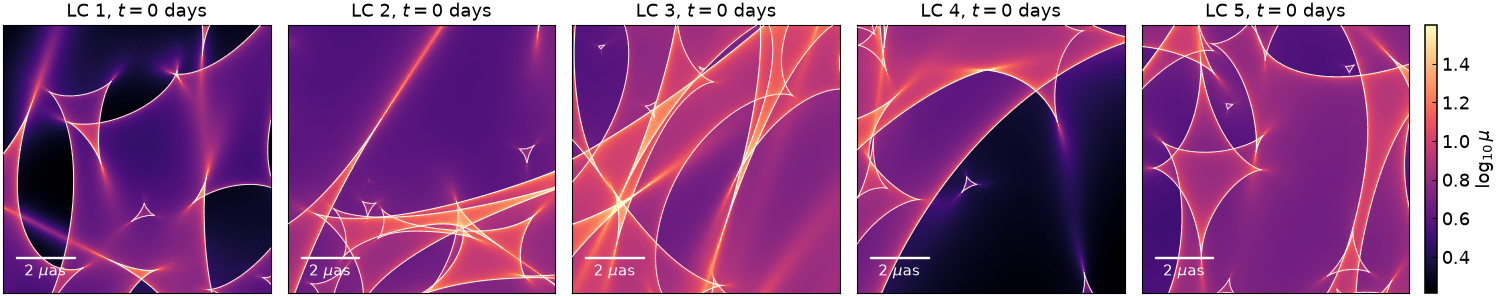

These map visualizations are excluded from the light-curve timings above.


In [4]:
import microcaustics as mc
sys.path.insert(0, str(EXAMPLES)) if str(EXAMPLES) not in sys.path else None
from training_set_support import plot_training_map_gallery, q2237_b_system

example_device = "cuda" if torch.cuda.is_available() else "cpu"
example_rays = 10_000_000 if torch.cuda.is_available() else 262_144
example_source_resolution = 1024 if torch.cuda.is_available() else 128
example_label_resolution = 8192 if torch.cuda.is_available() else 512
example_method = mc.production_ipm_config(rays=example_rays)
example_caustics = mc.CausticConfig(
    far_field_approx=example_method.far_field_approx, temporal_batch_size=1,
    anchor_count=9, gauge_count=9, float64_label_fallback=False,
)
example_frames = []
for metadata in metadata_rows:
    training_system = q2237_b_system(
        seed=int(metadata["seed"]), driver_seed=int(metadata["driver_seed"]),
        device=example_device, times_days=torch.tensor([0.0, 1.0]),
        source_resolution=example_source_resolution,
        label_resolution=example_label_resolution,
    )
    example_frames.append(next(iter(training_system.simulation.dynamic_labeled_maps(
        training_system.lens_region, training_system.source_grid,
        training_system.lens_grid, [0.0], method=example_method,
        map_schedule=mc.production_dynamic_config(),
        caustic_config=example_caustics,
    ))))

plot_training_map_gallery(
    example_frames, OUTPUT / "five_q2237_b_maps.pdf"
)
plt.show()
print("These map visualizations are excluded from the light-curve timings above.")


For a larger set or several GPUs, use `python examples/generate_q2237_training_set.py --count 1000 --gpus 0 1 2 3`. One persistent worker is pinned to each GPU. Files already completed are reused after interruption.

## Prior-sampled simulation datasets\n\nThe following section continues the workflow with the complementary use case.\n

## Training sets from explicit lens and disk priors

This notebook samples five independent macroimages and accretion disks from compact, documented demonstration priors. These are not a population model. A scientific inference run should supply survey- and selection-aware priors.

Every source returns physical Jy and is plotted in AB magnitudes. Each row compares microlensing alone with microlensing plus an intrinsic broken-PSD realization. The intrinsic source is evaluated daily while the expensive dynamic maps and source-center labels are evaluated every 25 days. Daily flux uses the two bracketing map--source contractions, so daily maps are never materialized. The same three source-center diagnostics used elsewhere are shown. They are $\log_{10}\mu$, crossing, and $d_{\rm caustic}$. Only the center and anchor/gauge queries are evaluated. Full binary and distance maps remain explicit opt-in diagnostics. Fixed tensor shapes allow each persistent GPU worker to reuse compiled kernels even though the convergence, shear, redshifts, disk parameters, velocities, stars, trajectories, and variability change. The first compatible example pays any missing compilation cost; later examples reuse that specialization.

This executable notebook pins `--seed 41000`, making all five examples exactly reconstructible. The command-line generator instead draws and prints a fresh base seed when `--seed` is omitted, and records each resolved realization seed in its JSON metadata.

## Demonstration priors and their limits

These bounds were deliberately chosen as broad, transparent *demonstration priors* spanning ordinary galaxy-scale quasar macroimages and thin disks. They were not inferred from a lens survey and should not be interpreted as a population distribution. The draws are independent except for $z_s>z_l+0.4$ and the macro-Jacobian guard described below. For a scientific training set, replace them with a joint, selection-aware prior or posterior samples for the systems being modeled.

| Quantity | Sampling distribution | Demonstration rationale |
|, |, |, |
| Lens redshift $z_l$ | $\mathcal U(0.15,0.75)$ | Broad galaxy-lens redshift interval |
| Source redshift $z_s$ | $\mathcal U(\max[1,z_l+0.4],3)$ | Background quasars with clear lens--source separation |
| Convergence $\kappa$ | $\mathcal U(0.20,0.65)$ | Spans common local macroimage environments |
| Shear $\gamma$ | $\mathcal U(0.10,0.60)$ | Spans weak through strong local tidal fields |
| Smooth-matter fraction $s$ | $\mathcal U(0,0.5)$ | Samples all-stellar through mixed smooth/compact surface density |
| Shear angle | $\mathcal U(0,180^\circ)$ | Isotropic sky orientation |
| $\log_{10}(M_{\rm BH}/M_\odot)$ | $\mathcal U(7.5,9.5)$ | Broad quasar black-hole mass interval |
| Eddington ratio | log-uniform on $[10^{-1.3},10^{-0.05}]$ | Covers sub-Eddington thin disks over a wide luminosity range |
| Spin $a$ | $\mathcal U(-0.8,0.95)$ | Broad retrograde-to-prograde interval without extremal endpoints |
| Inclination $i$ | uniform in $\cos i$ for $0\le i\le60^\circ$ | Isotropic type-1 orientations with more edge-on systems excluded |
| Disk position angle | $\mathcal U(0,180^\circ)$ | Isotropic projected orientation |

Draws are rejected when either absolute macro-Jacobian eigenvalue, $|1-\kappa\pm\gamma|$, is below 0.12. This keeps a compact tutorial away from nearly singular macro configurations. Compact objects follow a Salpeter mass function with mass ratio 100 and mean mass $0.3\,M_\odot$. Their positions are uniform in a circular lens field, and the compact convergence is $(1-s)\kappa$. The source field encloses 99.9% of the reddest-band thin-disk flux and adds a 5% margin. The circular lens-field diameter is 1.5 times the diagonal of the 1%-light-loss rectangular estimate.

A fixed ray count is a compute budget, not a universal accuracy guarantee. Changing redshift, macro magnification, lens-field size, and disk angular size changes how many traced polygons resolve each source pixel. The metadata sidecar records these quantities so a production data generator can enforce a convergence criterion, increase `rays`, or adjust source resolution for difficult draws.

In [5]:
from pathlib import Path
import json, os, subprocess, sys
import matplotlib.pyplot as plt
import numpy as np
import torch
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
NOTEBOOK_DIR = Path.cwd()
repository_examples = Path(mcp.__file__).resolve().parents[3] / 'examples'
local_examples = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR / 'examples'
EXAMPLES = next(path for path in (local_examples, repository_examples) if (path / 'generate_random_training_set.py').is_file())
OUTPUT = NOTEBOOK_DIR / 'generated' / 'random_training_set'
OUTPUT.mkdir(parents=True, exist_ok=True)
TRITON_CACHE = OUTPUT / 'triton_cache' / 'notebook'
TRITON_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('TRITON_CACHE_DIR', str(TRITON_CACHE.resolve()))
print('CUDA:', torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'portable CPU smoke mode')

CUDA: True NVIDIA GeForce RTX 5070 Ti


In [6]:
command = [sys.executable, str(EXAMPLES / 'generate_random_training_set.py'), '--count', '5', '--seed', '41000', '--output-dir', str(OUTPUT), '--overwrite']
if torch.cuda.is_available():
    command += ['--gpus', '0']
else:
    command += ['--device', 'cpu', '--rays', '262144', '--source-resolution', '128', '--label-resolution', '512', '--epochs', '13']
subprocess.run(command, check=True)

CompletedProcess(args=['c:\\Users\\fagin\\miniforge3\\envs\\torch\\python.exe', 'C:\\Users\\fagin\\Desktop\\microlensing\\microcaustics_package\\examples\\generate_random_training_set.py', '--count', '5', '--seed', '41000', '--output-dir', 'C:\\Users\\fagin\\Desktop\\microlensing\\microcaustics_package\\build\\notebook_execution\\04_simulation_datasets_jvpwk_6c\\generated\\random_training_set', '--overwrite', '--gpus', '0'], returncode=0)

first call (compile + execute)=6.398 s
warmed end-to-end LC + center labels median=6.066 s
warmed dynamic maps + center labels median=nan s
warmed map--source contractions median=nan s
warmed physical-source brightness median=nan s
Each row uses 147 dynamic maps/label epochs and 3,651 daily source samples.


C:\Users\fagin\AppData\Local\Temp\ipykernel_524\487275842.py:10: RuntimeWarning: All-NaN slice encountered
  print(f"warmed dynamic maps + center labels median={np.nanmedian(dynamic_time[1:]):.3f} s")
C:\Users\fagin\AppData\Local\Temp\ipykernel_524\487275842.py:11: RuntimeWarning: All-NaN slice encountered
  print(f"warmed map--source contractions median={np.nanmedian(contraction_time[1:]):.3f} s")
C:\Users\fagin\AppData\Local\Temp\ipykernel_524\487275842.py:12: RuntimeWarning: All-NaN slice encountered
  print(f"warmed physical-source brightness median={np.nanmedian(source_time[1:]):.3f} s")


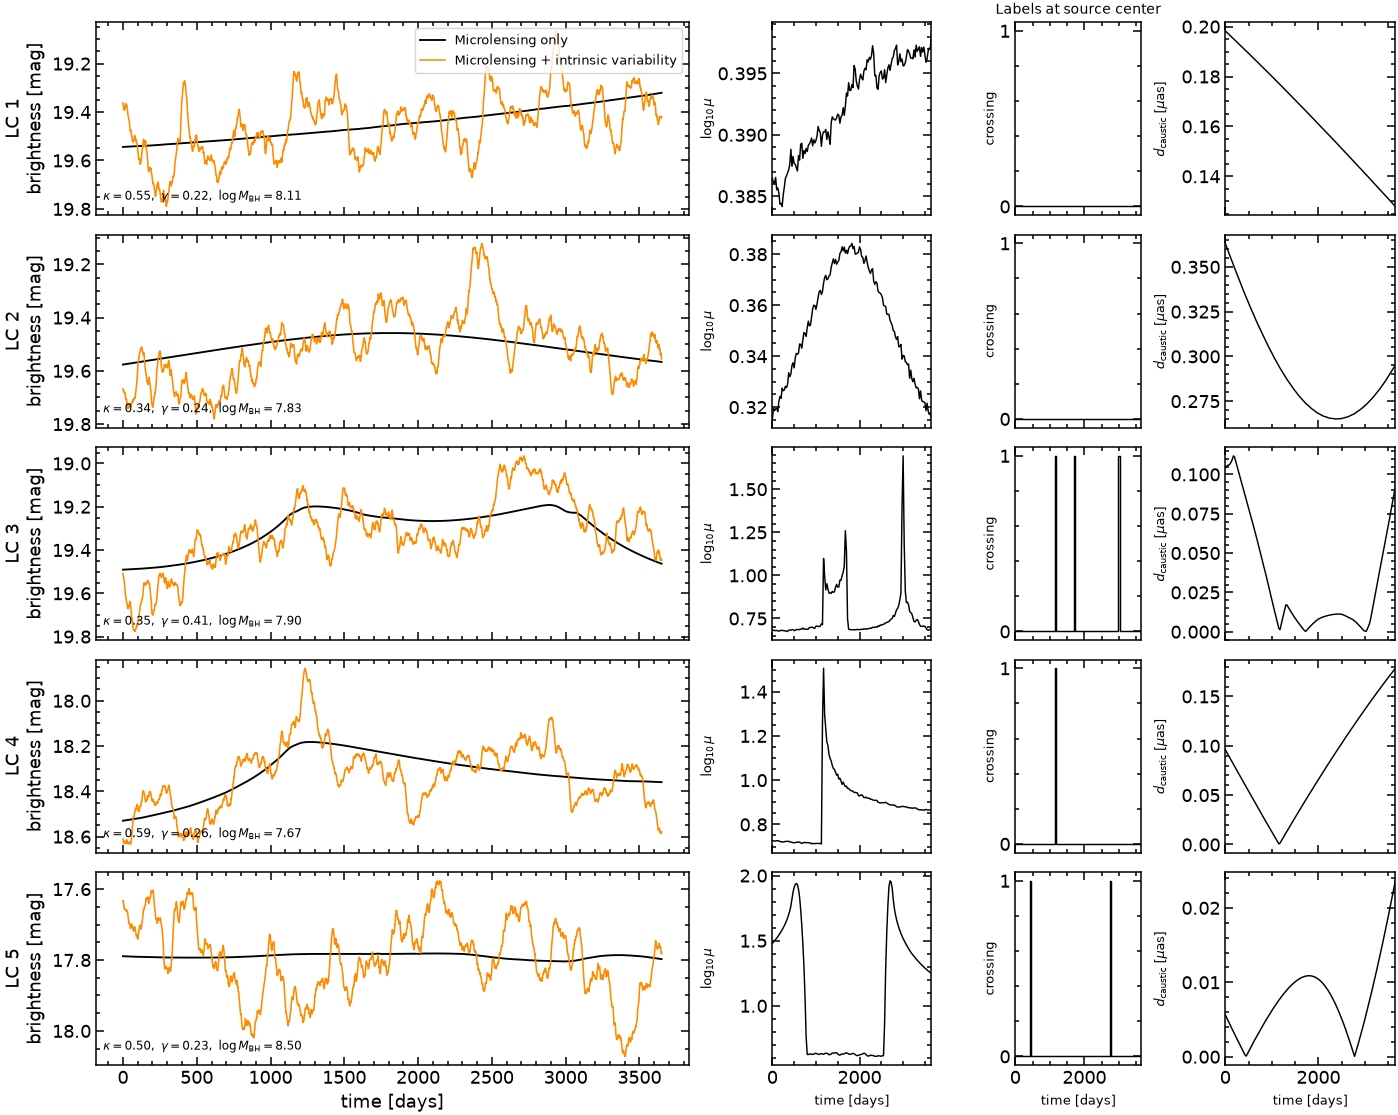

In [7]:
paths = sorted(OUTPUT.glob("light_curve_*.npz"))[:5]
metadata_rows = [json.loads(path.with_suffix(".json").read_text()) for path in paths]
runtimes = np.asarray([row["runtime_seconds"] for row in metadata_rows], dtype=float)
components = [row.get("timing_components_seconds", {}) for row in metadata_rows]
dynamic_time = np.asarray([float(item.get("dynamic_maps", np.nan)) for item in components])
source_time = np.asarray([float(item.get("source_brightness", np.nan)) for item in components])
contraction_time = np.asarray([float(item.get("map_source_contractions", np.nan)) for item in components])
print(f"first call (compile + execute)={runtimes[0]:.3f} s")
print(f"warmed end-to-end LC + center labels median={np.median(runtimes[1:]):.3f} s")
print(f"warmed dynamic maps + center labels median={np.nanmedian(dynamic_time[1:]):.3f} s")
print(f"warmed map--source contractions median={np.nanmedian(contraction_time[1:]):.3f} s")
print(f"warmed physical-source brightness median={np.nanmedian(source_time[1:]):.3f} s")
print("Each row uses 147 dynamic maps/label epochs and 3,651 daily source samples.")

records = [np.load(path) for path in paths]
sys.path.insert(0, str(EXAMPLES)) if str(EXAMPLES) not in sys.path else None
from training_set_support import plot_training_light_curves

annotations = [
    rf'$\kappa={row["kappa"]:.2f},\ \gamma={row["gamma"]:.2f},\ '
    rf'\log M_{{\rm BH}}={row["log10_black_hole_mass_solar"]:.2f}$'
    for row in metadata_rows
]
plot_training_light_curves(
    records,
    OUTPUT / "five_prior_sampled_training_curves.pdf",
    annotations=annotations,
)
plt.show()


## Inspect one magnification map from every realization

The compact training records store light curves and labels rather than all $1024^2$ maps. This cell reconstructs **each** sampled physical realization from its recorded seed and generates its $t=0$ map. It runs **after** the timing measurements and is excluded from them. Every map uses the same production $N=10^7$, $k=2$, $r=2$, $v=4$ dynamic method and overlays the same-epoch mapped caustics. The shared color scale makes the five physically different realizations directly comparable.

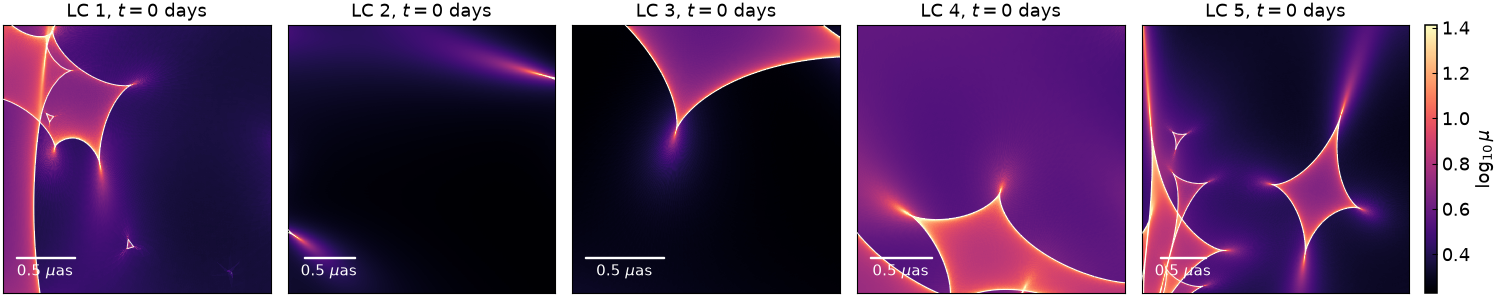

These map visualizations are excluded from the light-curve timings above.


In [8]:
import microcaustics as mc
sys.path.insert(0, str(EXAMPLES)) if str(EXAMPLES) not in sys.path else None
from training_set_support import plot_training_map_gallery, random_system

example_device = "cuda" if torch.cuda.is_available() else "cpu"
example_rays = 10_000_000 if torch.cuda.is_available() else 262_144
example_source_resolution = 1024 if torch.cuda.is_available() else 128
example_label_resolution = 8192 if torch.cuda.is_available() else 512
example_method = mc.production_ipm_config(rays=example_rays)
example_caustics = mc.CausticConfig(
    far_field_approx=example_method.far_field_approx, temporal_batch_size=1,
    anchor_count=9, gauge_count=9, float64_label_fallback=False,
)
example_frames = []
for metadata in metadata_rows:
    training_system = random_system(
        seed=int(metadata["seed"]),
        device=example_device, times_days=torch.tensor([0.0, 1.0]),
        source_resolution=example_source_resolution,
        label_resolution=example_label_resolution,
    )
    example_frames.append(next(iter(training_system.simulation.dynamic_labeled_maps(
        training_system.lens_region, training_system.source_grid,
        training_system.lens_grid, [0.0], method=example_method,
        map_schedule=mc.production_dynamic_config(),
        caustic_config=example_caustics,
    ))))

source_widths = [frame.magnification_map.grid.field_of_view_uas[0] for frame in example_frames]
plot_training_map_gallery(
    example_frames, OUTPUT / "five_prior_sampled_maps.pdf",
    source_widths_uas=source_widths,
)
plt.show()
print("These map visualizations are excluded from the light-curve timings above.")


The equivalent multi-GPU command is `python examples/generate_random_training_set.py --count 1000 --gpus 0 1 2 3`. The JSON sidecar records every sampled physical parameter. The compressed array contains fluxes, unlensed fluxes, bands, center labels, and crossing events.